In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
# Import dataset from performance.csv
df = pd.read_csv('C:/Users/MSIS/Downloads/AML/MLLabprojects/data/performance.csv')

In [4]:
# input: study hours (assuming the first column is the feature)
x = df.iloc[:, 0].values.reshape(-1, 1)

In [5]:
x

array([[2],
       [3],
       [4],
       [5],
       [6],
       [7],
       [8],
       [9]])

In [6]:
x.reshape(1, -1)

array([[2, 3, 4, 5, 6, 7, 8, 9]])

In [7]:
# output: marks (assuming the second column is the target)
y = df.iloc[:, 1].values
y

array([60, 65, 70, 75, 80, 85, 90, 95])

In [8]:
# create and train the model
model = LinearRegression()
model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[5.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,50
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[6.48]


In [9]:
# display the regression parameters
print("Intercept:", model.intercept_)
print("slope:", model.coef_[0])

Intercept: 49.999999999999986
slope: 5.000000000000003


In [10]:
# predict marks for six study hours
new_data = np.array([[6]])
predicted_mark = model.predict(new_data)

In [11]:
print("predicted mark:", predicted_mark[0])

predicted mark: 80.0


In [12]:
# predictions for the original observations
y_pred = model.predict(x)
y_pred

array([60., 65., 70., 75., 80., 85., 90., 95.])

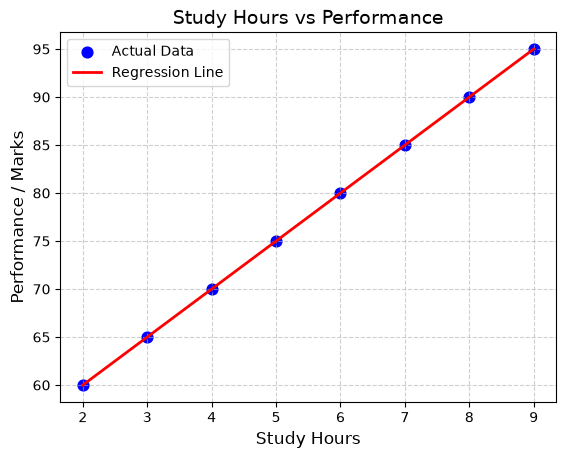

In [13]:
plt.scatter(x, y, color='blue', label='Actual Data', s=60)
plt.plot(x, y_pred, color='red', linewidth=2, label='Regression Line')

# Formatting plot
plt.title('Study Hours vs Performance', fontsize=14)
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Performance / Marks', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Model Evaluation

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [15]:
mse = mean_squared_error(y, y_pred)
mse

6.310887241768095e-30

In [16]:
rmse = np.sqrt(mse)
rmse

np.float64(2.5121479338940403e-15)

In [17]:
mae = mean_absolute_error(y, y_pred)
mae

8.881784197001252e-16

In [18]:
r2 = r2_score(y, y_pred)
r2

1.0

In [19]:
print("--- Model Evaluation Summary ---")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2 Score):", r2)

--- Model Evaluation Summary ---
Mean Squared Error (MSE): 6.310887241768095e-30
Root Mean Squared Error (RMSE): 2.5121479338940403e-15
Mean Absolute Error (MAE): 8.881784197001252e-16
R-squared (R2 Score): 1.0


Train-test Split example

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

In [22]:
model_split = LinearRegression()
model_split.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[5.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,50
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[2.96]


In [23]:
# Predict on test set
y_pred_test = model_split.predict(X_test)

In [24]:
# Calculate metrics
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

In [25]:
y_pred_test = model_split.predict(X_test)
y_pred_test

array([65., 85., 60., 95.])

In [26]:
print("Test Set (y_test):", y_test)
print("Predicted Values (y_pred_test):", y_pred_test)
print("Test MSE:", mse_test)
print("Test MAE:", mae_test)
print("Test R2 Score:", r2_test)

Test Set (y_test): [65 85 60 95]
Predicted Values (y_pred_test): [65. 85. 60. 95.]
Test MSE: 1.0097419586828951e-28
Test MAE: 7.105427357601002e-15
Test R2 Score: 1.0


Multiple Linear Regression

In [27]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load dataset from performance.csv
df = pd.read_csv('C:/Users/MSIS/Downloads/AML/MLLabprojects/data/performance.csv')

In [28]:
# Select feature column (x) and target variable (y) from performance.csv
x = df[['Study_Hours']]
y = df['Final_Marks']

In [29]:
model = LinearRegression()
model.fit(x, y)

print("Intercept:", model.intercept_)

Intercept: 27.904761904761898


In [30]:
coefficient_table = pd.DataFrame({
    "feature": x.columns,
    "coefficient": model.coef_
})

print(coefficient_table)

       feature  coefficient
0  Study_Hours     6.630952


In [31]:
print(coefficient_table)

       feature  coefficient
0  Study_Hours     6.630952


In [32]:
new_student = pd.DataFrame({
    "Study_Hours": [6]
})

print(new_student)

   Study_Hours
0            6


In [33]:
prediction = model.predict(new_student)
print("predicted final marks:", prediction[0])

predicted final marks: 67.69047619047619


c:\Users\MSIS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


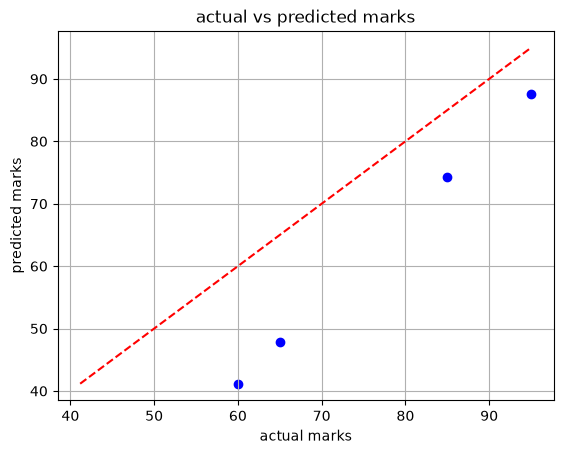

In [34]:
# 1. Make sure predictions are generated on X_test
y_pred = model.predict(X_test)

# 2. Plot actual vs predicted values
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color="blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--"
)

plt.xlabel("actual marks")
plt.ylabel("predicted marks")
plt.title("actual vs predicted marks")
plt.grid(True)
plt.show()

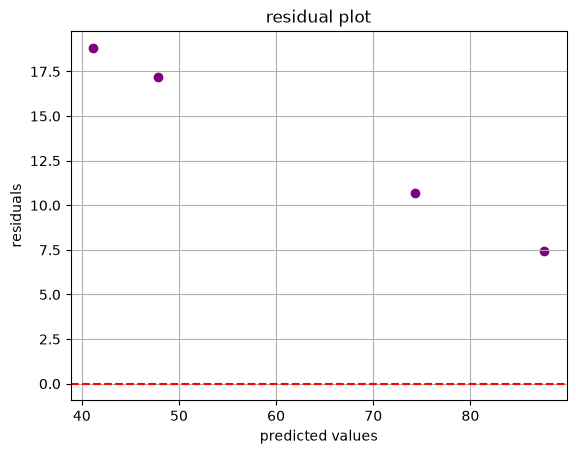

In [35]:
# Calculate residuals on test set predictions
residuals = y_test - y_pred

# Plot residual values vs predicted values
plt.scatter(y_pred, residuals, color="purple")
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("predicted values")
plt.ylabel("residuals")
plt.title("residual plot")
plt.grid(True)
plt.show()